In [1]:
#After users signup, how many continue using the product later?”
#Example:
#Signup Users	Returned After 7 Days
#   100	                    35
#Retention:35%

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
events_df = pd.read_csv('../data/raw/events.csv')
events_df['timestamp'] = pd.to_datetime(events_df['timestamp']) # Convert timestamp to datetime

events_df['event_date'] = events_df['timestamp'].dt.date # Extract date from timestamp

In [6]:
signup_dates = events_df[
    events_df['event'] == 'signup'
][['user_id', 'event_date']]
# Merge signup dates with events to track user activity

In [7]:
signup_dates.columns = ['user_id', 'signup_date']
#rename columns for clarity

events_df = events_df.merge(
    signup_dates,
    on='user_id'
)
# Calculate days since signup for each event

In [8]:
events_df['days_since_signup'] = (
    pd.to_datetime(events_df['event_date']) -
    pd.to_datetime(events_df['signup_date'])
).dt.days

#calculate days since signup for each event to check how long users continue returning after signup. This will help us understand user retention over time.

In [9]:
events_df.head()

,user_id,event,timestamp,variant,event_date,signup_date,days_since_signup
0,1,signup,2026-05-03 20:02:05,B,2026-05-03,2026-05-03,0
1,1,activation,2026-05-04 01:02:05,B,2026-05-04,2026-05-03,1
2,2,signup,2026-05-07 13:25:22,B,2026-05-07,2026-05-07,0
3,2,activation,2026-05-08 21:25:22,B,2026-05-08,2026-05-07,1
4,3,signup,2026-03-13 14:58:41,B,2026-03-13,2026-03-13,0


In [10]:
retention = events_df.groupby(
    'days_since_signup'
)['user_id'].nunique()

# Plot retention curve to visualize how user retention changes over time after signup.

In [9]:
print(retention.head(15))

days_since_signup
0     5000
1     1757
2     1024
3      232
4      278
5      247
6      275
7      254
8      213
9      125
10      49
11      46
12      50
13      44
14      38
Name: user_id, dtype: int64


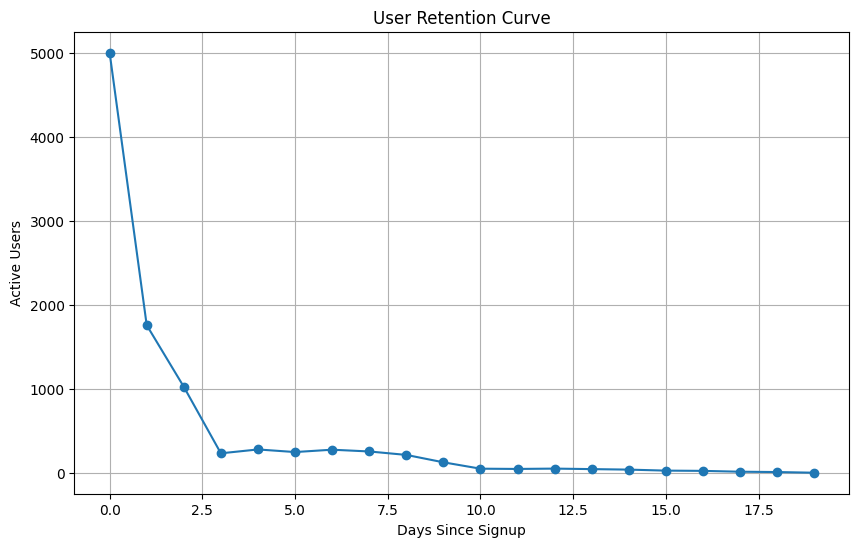

In [10]:
plt.figure(figsize=(10,6))

plt.plot(
    retention.index,
    retention.values,
    marker='o'
)

plt.title('User Retention Curve')
plt.xlabel('Days Since Signup')
plt.ylabel('Active Users')

plt.grid(True)

plt.show()

In [11]:
initial_users = retention.iloc[0]

retention_percentage = (
    retention / initial_users
) * 100

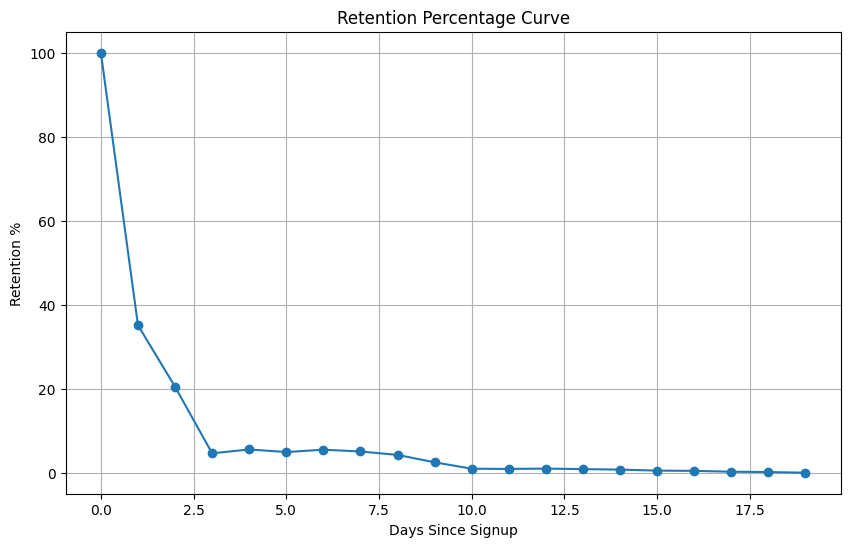

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    retention_percentage.index,
    retention_percentage.values,
    marker='o'
)

plt.title('Retention Percentage Curve')
plt.xlabel('Days Since Signup')
plt.ylabel('Retention %')

plt.grid(True)

plt.show()

In [ ]:
#I analyzed user retention by tracking activity relative to signup date, calculated retention decay over time, and visualized churn behavior using retention curves.